# Reto de Vision: Clasificacion Automatizada con CNN

**Escenario:** Optimizacion de la cadena de suministro digital de una empresa de e-commerce de moda mediante una Red Neuronal Convolucional (CNN) que clasifica automaticamente imagenes de producto, reduciendo el etiquetado manual y sus errores asociados.

**Dataset:** Fashion MNIST (10 categorias de prendas, 70,000 imagenes en escala de grises de 28x28 pixeles).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models

np.random.seed(42)

CLASS_NAMES = ["Camiseta/Top", "Pantalon", "Sueter", "Vestido", "Abrigo",
               "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botin"]

/Users/alejandroalvarenga/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Fase 1: Data Wrangling para Imagenes

### Paso 1 y 2: Preparacion de tensores

Se realiza la carga nativa del dataset desde Keras, la separacion de un conjunto de validacion, la normalizacion de los pixeles al rango [0, 1] y el ajuste de los tensores a 4 dimensiones para incluir el canal de color.

Para evitar fuga de datos, el conjunto de prueba (`x_test`, `y_test`) se mantiene completamente aislado hasta la evaluacion final. La particion de validacion se extrae unicamente del conjunto de entrenamiento, usando estratificacion para conservar la proporcion de clases.

In [2]:
# Carga nativa de Fashion MNIST desde Keras
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

print("Forma original de entrenamiento:", x_train_full.shape, y_train_full.shape)
print("Forma original de prueba:", x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Forma original de entrenamiento: (60000, 28, 28) (60000,)
Forma original de prueba: (10000, 28, 28) (10000,)


In [3]:
# Particion estratificada train/validacion (el test set no se toca aqui)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.1,
    random_state=42,
    stratify=y_train_full
)

print("Entrenamiento:", x_train.shape, y_train.shape)
print("Validacion:   ", x_val.shape, y_val.shape)
print("Prueba:       ", x_test.shape, y_test.shape)

Entrenamiento: (54000, 28, 28) (54000,)
Validacion:    (6000, 28, 28) (6000,)
Prueba:        (10000, 28, 28) (10000,)


In [4]:
# Normalizacion al rango [0, 1]
x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape a 4 dimensiones (lote, 28, 28, 1) para incluir el canal de color
x_train = x_train.reshape(-1, 28, 28, 1)
x_val = x_val.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Tensores finales:")
print("x_train:", x_train.shape, "rango:", x_train.min(), "-", x_train.max())
print("x_val:  ", x_val.shape)
print("x_test: ", x_test.shape)

Tensores finales:
x_train: (54000, 28, 28, 1) rango: 0.0 - 1.0
x_val:   (6000, 28, 28, 1)
x_test:  (10000, 28, 28, 1)


### Verificacion visual del preprocesamiento

Se inspeccionan algunas muestras para confirmar que el redimensionamiento y la normalizacion no distorsionaron el contenido de las imagenes.

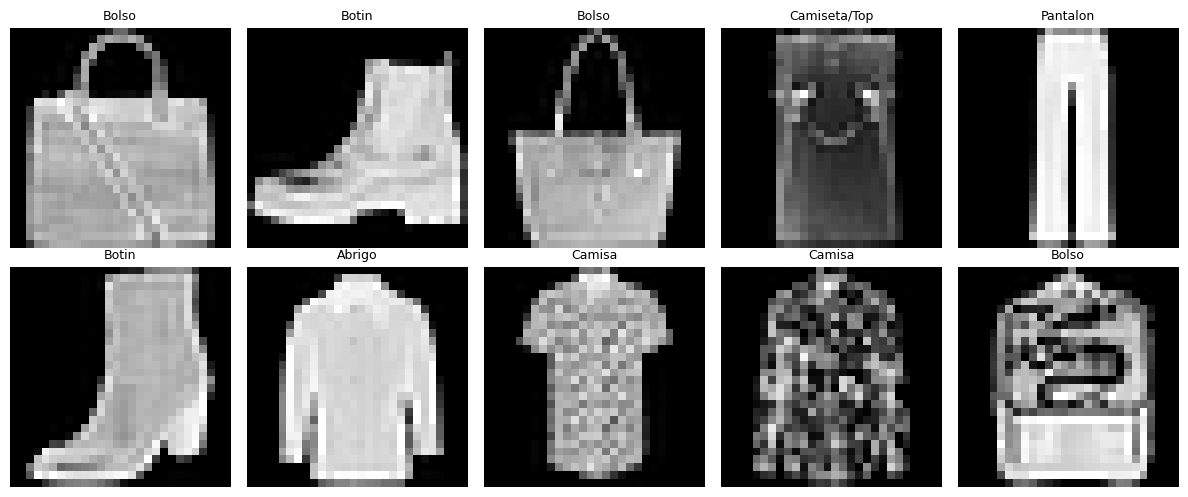

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].squeeze(), cmap="gray")
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Fase 2: Diseno de la CNN y Entrenamiento

### Requisitos de arquitectura

- 2 capas `Conv2D` (ReLU) intercaladas con 2 capas `MaxPooling2D`.
- Capa de aplanado (`Flatten`) seguida de capas densas.
- Capa de salida con 10 neuronas y activacion `softmax`.

Se agrega una capa `Dropout` antes de la salida para reducir el sobreajuste sin alterar los requisitos de la arquitectura.

In [6]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Compilacion y entrenamiento

Optimizador **Adam**, funcion de perdida `sparse_categorical_crossentropy` (adecuada porque las etiquetas son enteros y no vectores one-hot), metrica de precision, y entrenamiento durante un minimo de 10 epocas con seguimiento en el conjunto de validacion.

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=12,
    batch_size=128,
    verbose=2
)

Epoch 1/12
422/422 - 7s - 17ms/step - accuracy: 0.7725 - loss: 0.6245 - val_accuracy: 0.8603 - val_loss: 0.3810
Epoch 2/12
422/422 - 6s - 15ms/step - accuracy: 0.8570 - loss: 0.3941 - val_accuracy: 0.8860 - val_loss: 0.3191
Epoch 3/12
422/422 - 7s - 16ms/step - accuracy: 0.8748 - loss: 0.3422 - val_accuracy: 0.8907 - val_loss: 0.2924
Epoch 4/12
422/422 - 6s - 15ms/step - accuracy: 0.8874 - loss: 0.3099 - val_accuracy: 0.9022 - val_loss: 0.2714
Epoch 5/12
422/422 - 6s - 15ms/step - accuracy: 0.8936 - loss: 0.2907 - val_accuracy: 0.9068 - val_loss: 0.2500
Epoch 6/12
422/422 - 6s - 13ms/step - accuracy: 0.9015 - loss: 0.2668 - val_accuracy: 0.9137 - val_loss: 0.2427
Epoch 7/12
422/422 - 6s - 14ms/step - accuracy: 0.9061 - loss: 0.2536 - val_accuracy: 0.9107 - val_loss: 0.2380
Epoch 8/12
422/422 - 6s - 13ms/step - accuracy: 0.9129 - loss: 0.2374 - val_accuracy: 0.9130 - val_loss: 0.2334
Epoch 9/12
422/422 - 6s - 13ms/step - accuracy: 0.9170 - loss: 0.2243 - val_accuracy: 0.9160 - val_loss:

## Fase 3: Evaluacion Analitica

### Evolucion de Loss y Accuracy

Se grafica la evolucion de ambas metricas en entrenamiento y validacion para diagnosticar si el modelo esta generalizando correctamente o presenta sobreajuste (senal: la curva de validacion se separa hacia arriba/abajo de la de entrenamiento).

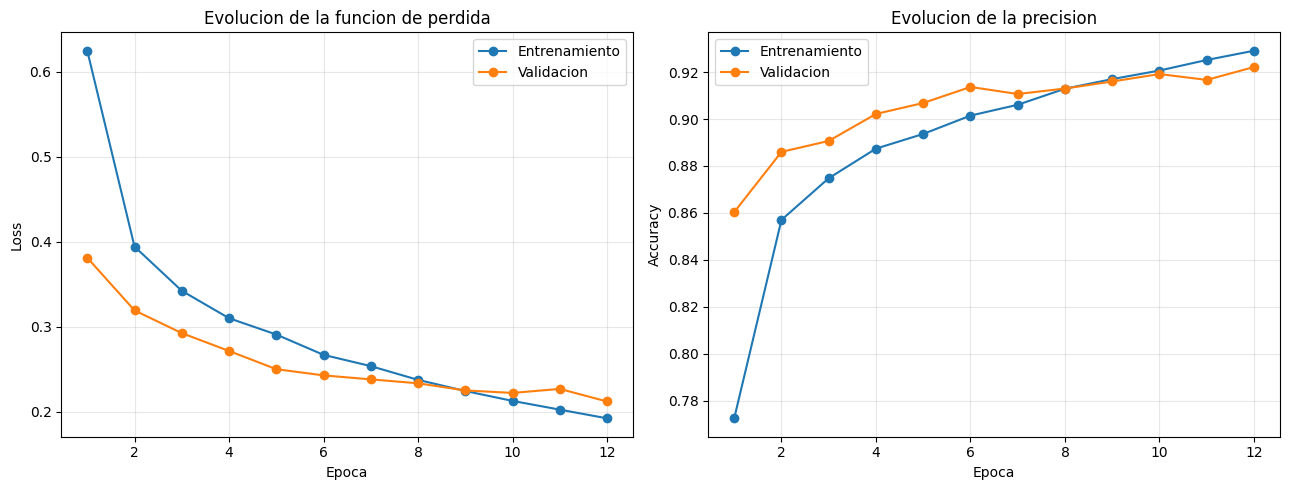

In [8]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_range, loss, label="Entrenamiento", marker="o")
axes[0].plot(epochs_range, val_loss, label="Validacion", marker="o")
axes[0].set_title("Evolucion de la funcion de perdida")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, acc, label="Entrenamiento", marker="o")
axes[1].plot(epochs_range, val_acc, label="Validacion", marker="o")
axes[1].set_title("Evolucion de la precision")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Perdida en prueba:   {test_loss:.4f}")
print(f"Precision en prueba: {test_acc:.4f}")

Perdida en prueba:   0.2360
Precision en prueba: 0.9139


### Matriz de confusion

La matriz de confusion permite identificar en que categorias especificas se equivoca el modelo, informacion clave para el analisis de negocio.

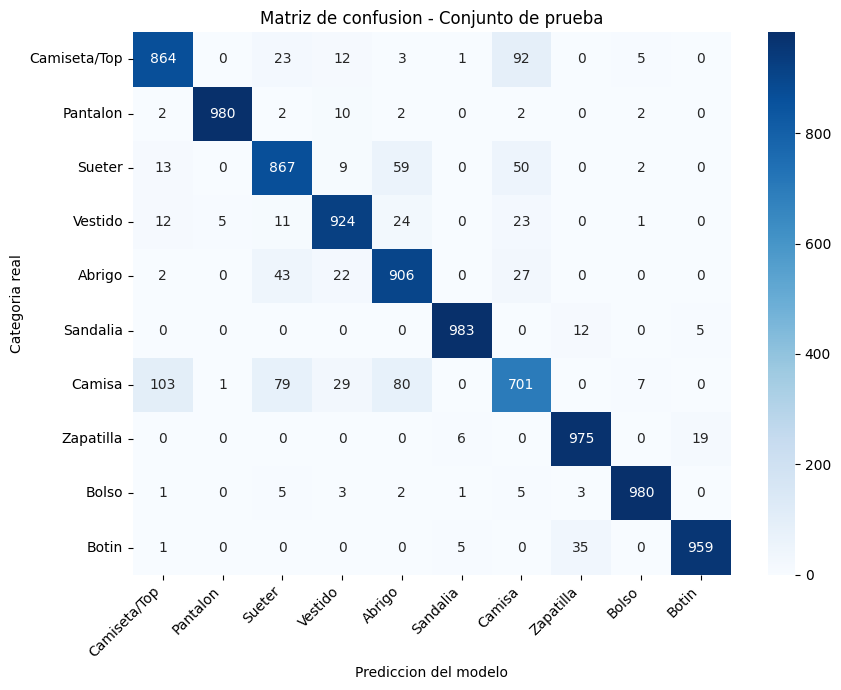

In [10]:
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Prediccion del modelo")
plt.ylabel("Categoria real")
plt.title("Matriz de confusion - Conjunto de prueba")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

Camiseta/Top       0.87      0.86      0.86      1000
    Pantalon       0.99      0.98      0.99      1000
      Sueter       0.84      0.87      0.85      1000
     Vestido       0.92      0.92      0.92      1000
      Abrigo       0.84      0.91      0.87      1000
    Sandalia       0.99      0.98      0.98      1000
      Camisa       0.78      0.70      0.74      1000
   Zapatilla       0.95      0.97      0.96      1000
       Bolso       0.98      0.98      0.98      1000
       Botin       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [12]:
# Identificacion de los pares de clases con mas confusiones (fuera de la diagonal)
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)

pares = []
for i in range(10):
    for j in range(10):
        if i != j and cm_off_diag[i, j] > 0:
            pares.append((cm_off_diag[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))

pares.sort(reverse=True)
print("Pares de clases mas confundidos (real -> predicho : numero de casos):")
for count, real, pred in pares[:8]:
    print(f"  {real} -> {pred} : {count}")

Pares de clases mas confundidos (real -> predicho : numero de casos):
  Camisa -> Camiseta/Top : 103
  Camiseta/Top -> Camisa : 92
  Camisa -> Abrigo : 80
  Camisa -> Sueter : 79
  Sueter -> Abrigo : 59
  Sueter -> Camisa : 50
  Abrigo -> Sueter : 43
  Botin -> Zapatilla : 35


## Analisis de negocio

**Pregunta:** ¿En que categorias se confunde mas el modelo? Explica el impacto financiero de estos errores y como los solucionarias.

**Patron de error observado**

La matriz de confusion muestra que el error se concentra de forma sistematica entre prendas de la parte superior del cuerpo: Camiseta/Top, Sueter, Camisa y Abrigo. Estas cuatro categorias comparten silueta general en una imagen de 28x28 pixeles en escala de grises (mangas, cuello, corte del torso), por lo que el modelo confunde con mayor frecuencia una Camisa con una Camiseta/Top o con un Sueter, y un Abrigo con un Sueter. En contraste, categorias con siluetas muy distintivas (Pantalon, Sandalia, Bolso, Botin) presentan muy pocos errores.

**Impacto financiero**

En un sistema de etiquetado automatico para e-commerce, este tipo de confusion tiene consecuencias operativas y comerciales concretas:

- Catalogacion incorrecta: una prenda etiquetada en la categoria equivocada no aparece en los filtros de busqueda correctos (por ejemplo, un cliente que filtra por "camisas" no encuentra un producto mal etiquetado como "sueter"), lo que reduce la visibilidad del producto y, por tanto, las ventas potenciales de ese articulo.
- Errores logisticos en almacen: si el sistema de picking o de ubicacion en bodega depende de la categoria predicha, una prenda mal clasificada puede terminar en la zona de almacenamiento equivocada, incrementando el tiempo de busqueda y el costo operativo de preparacion de pedidos.
- Devoluciones y insatisfaccion del cliente: si la categoria incorrecta se refleja en la descripcion o en las expectativas del producto (por ejemplo, un abrigo mostrado con especificaciones tipicas de un sueter), aumenta la probabilidad de devolucion, generando costos de logistica inversa y afectando la percepcion de calidad de la tienda.
- Costo de revision manual: cada error detectado eventualmente requiere que un operador humano revise y corrija la etiqueta, lo cual reintroduce el costo de mano de obra que la CNN buscaba eliminar, aunque en una proporcion mucho menor que un etiquetado totalmente manual.

Aunque la precision global del modelo es alta, el costo de un error no es uniforme: los errores concentrados en prendas de valor mas alto (abrigos, sueteres) o en categorias con mayor volumen de catalogo tienen un impacto financiero desproporcionadamente mayor que un error aislado en una categoria de bajo volumen.

**Soluciones propuestas**

1. Revision humana dirigida por confianza: enrutar automaticamente a revision manual unicamente las predicciones cuya probabilidad maxima de softmax este por debajo de un umbral (por ejemplo 0.7) o cuya segunda probabilidad mas alta corresponda a una de las categorias historicamente confundidas. Esto concentra el esfuerzo humano solo en los casos de riesgo real en lugar de revisar todo el catalogo.
2. Aumento de datos (data augmentation) enfocado en las clases confundidas: aplicar rotaciones leves, zoom y variaciones de contraste sobre las imagenes de Camisa, Camiseta/Top, Sueter y Abrigo para que el modelo aprenda variaciones de textura y corte que distingan mejor estas prendas.
3. Arquitectura mas profunda o con mayor resolucion de entrada: agregar un tercer bloque convolucional o trabajar con imagenes de mayor resolucion (cuando el proveedor de imagenes lo permita) para capturar detalles finos como textura de tela, tipo de cuello o presencia de botones, que son las senales que distinguen a estas prendas entre si.
4. Clasificador jerarquico en dos etapas: en una primera etapa agrupar categorias visualmente similares en una misma superclase (por ejemplo "prendas superiores"), y en una segunda etapa aplicar un clasificador especializado solo dentro de ese grupo, reduciendo el espacio de confusion en cada etapa.
5. Reentrenamiento periodico con casos corregidos: registrar los casos que el equipo humano corrige y reincorporarlos al conjunto de entrenamiento en ciclos periodicos, de forma que el modelo aprenda especificamente de sus errores historicos mas costosos.